# 06F - Domain-Aware Mixture Adapter Co-Attention SER

Notebook này phát triển từ `06D_update`, nhưng thêm một ý tưởng mới: **domain-aware mixture adapters**.

Vấn đề chính của project hiện tại không chỉ là thiếu feature. Speech emotion recognition trên 4 dataset bị lẫn 3 loại tín hiệu:

```text
emotion signal        = tín hiệu cảm xúc thật sự
speaker signal        = giọng riêng / timbre / pitch range / thói quen nói
dataset/domain signal = micro / môi trường thu / acted style / corpus bias
```

Mục tiêu 06F:

- giữ lõi mạnh nhất hiện tại: emotion2vec + temporal branch + spectral branch + co-attention;
- thêm **soft domain gate** để model tự nhận biết audio giống domain nào;
- thêm **mixture of dataset adapters** để hiệu chỉnh representation theo domain;
- vẫn dùng emotion classifier chung cho 6 cảm xúc;
- lưu domain mixture weights để phân tích và demo;
- giữ selective ensemble + batch log + zip output nhẹ.

6 nhãn cảm xúc:

```text
neutral, happy, sad, angry, fear, disgust
```

## Ý Tưởng Và Paper Reference

### 1. Vì sao cần domain-aware?

Kết quả trước cho thấy mô hình bị chặn quanh:

```text
combined_random ≈ 0.80 macro-F1
combined_strict_no_tess ≈ 0.70 macro-F1
```

Nguyên nhân lớn là 4 dataset không cùng phân phối:

- `CREMA-D`: nhiều speaker, đa dạng, khó hơn;
- `RAVDESS`: acted speech, sạch hơn;
- `TESS`: rất sạch, speaker nữ, cảm xúc rất rõ;
- `SAVEE`: ít speaker nam, phong cách khác.

Nếu ép toàn bộ đi qua một classifier y hệt, model phải tự xử lý cả emotion, speaker và domain. 06F tách rõ hơn bằng cách thêm adapter theo domain.

### 2. Domain-aware mixture adapter là gì?

`Domain gate` sinh ra trọng số mềm cho từng dataset/domain:

```text
z_base -> softmax -> [w_CREMA-D, w_RAVDESS, w_TESS, w_SAVEE]
```

Sau đó mỗi adapter hiệu chỉnh `z_base` theo một domain:

```text
z_domain =
  w1 * adapter_CREMA-D(z_base)
+ w2 * adapter_RAVDESS(z_base)
+ w3 * adapter_TESS(z_base)
+ w4 * adapter_SAVEE(z_base)
```

Đây là **soft mixture**, không phải chọn cứng. Vì vậy khi demo thực tế, audio không cần biết thuộc dataset nào; model tự chọn tỷ lệ adapter.

### 3. Co-attention vẫn giữ vai trò gì?

Co-attention cho phép pretrained emotion representation tương tác với temporal/spectral features:

```text
z_e2v hỏi temporal/spectral branch:
đoạn/feature nào đang hữu ích nhất cho emotion?
```

Reference:

- CA-MSER: Speech Emotion Recognition with Co-Attention based Multi-level Acoustic Information, https://arxiv.org/abs/2203.15326

### 4. Cross-corpus/domain SER liên quan gì?

Các nghiên cứu cross-corpus SER cho thấy mô hình trained trên một corpus thường giảm mạnh khi test trên corpus khác. Điều này ủng hộ việc phải xử lý domain/corpus shift.

Reference:

- Cross-corpus SER study, https://arxiv.org/abs/2207.02104
- ADDoG domain generalization for SER, https://arxiv.org/abs/1903.12094
- Self-supervised adversarial domain adaptation for SER, https://arxiv.org/abs/2204.08625

### 5. Loss function

06F dùng nhiều loss:

```text
L_total = L_emotion
        + λ_aux * L_branch_emotion
        + λ_domain * L_domain
        - λ_entropy * H(domain_gate)
```

Trong đó:

- `L_emotion`: loss chính cho 6 emotion;
- `L_branch_emotion`: loss phụ cho các branch để branch nào cũng học emotion;
- `L_domain`: loss phụ giúp domain gate/head học nhận biết dataset;
- `H(domain_gate)`: entropy của gate, giúp gate không collapse quá sớm vào một adapter duy nhất;
- `λ`: hệ số điều chỉnh mức ảnh hưởng của từng loss.

### 6. Selective ensemble

Không ép mọi branch tham gia. Model/head nào yếu trên validation sẽ bị giảm trọng số hoặc loại khỏi ensemble. Đây là bài học từ 06D_update: branch yếu có thể kéo tụt kết quả.

## Kiến Trúc 06F Full

```text
Input audio 16 kHz
   |
   |-- Preprocess
   |      trim silence
   |      RMS normalization
   |      fixed 4s crop-pad
   |
   |-- Branch A: Temporal acoustic
   |      MFCC + delta + delta-delta
   |      -> 1D-CNN
   |      -> BiLSTM
   |      -> attention pooling
   |      -> z_temporal
   |
   |-- Branch B: Spectrogram
   |      log-Mel + delta log-Mel + delta-delta log-Mel
   |      -> residual 2D-CNN
   |      -> SE/channel attention
   |      -> z_spectral
   |
   |-- Branch C: Pretrained emotion
   |      raw waveform
   |      -> frozen emotion2vec
   |      -> adapter MLP
   |      -> z_e2v
   |
   |-- Branch D: Statistical
          handcrafted stats
          -> stats MLP
          -> z_stats

Co-attention:
   temporal tokens <-> spectral tokens
   -> z_ts_context

Base fusion:
   concat[z_temporal, z_spectral, z_e2v, z_ts_context, z_stats]
   -> fusion MLP
   -> z_base

Domain-aware mixture:
   z_base -> domain_gate -> soft weights over dataset adapters
   z_base -> adapter_CREMA-D
   z_base -> adapter_RAVDESS
   z_base -> adapter_TESS
   z_base -> adapter_SAVEE
   weighted sum -> z_domain

Heads:
   z_domain -> emotion classifier -> p_deep_domain_aware
   z_base   -> domain head       -> p_domain
   branches -> auxiliary emotion heads

Final:
   selective validation-weighted ensemble
   -> final 6 emotion probabilities
```

### Giải thích thuật ngữ trong sơ đồ

- `MFCC`: đặc trưng mô tả spectral envelope theo thang Mel, thường dùng trong speech.
- `delta`, `delta-delta`: tốc độ và gia tốc thay đổi của feature theo thời gian.
- `log-Mel`: biểu diễn thời gian-tần số, giống ảnh âm thanh.
- `1D-CNN`: học pattern theo trục thời gian.
- `2D-CNN`: học pattern trên ảnh thời gian-tần số.
- `BiLSTM`: đọc chuỗi theo cả quá khứ và tương lai.
- `attention pooling`: học frame nào quan trọng hơn.
- `SE/channel attention`: học kênh feature nào quan trọng hơn.
- `emotion2vec frozen`: pretrained emotion representation, không fine-tune.
- `z_base`: representation tổng hợp trước khi xử lý domain.
- `domain gate`: mạng nhỏ sinh trọng số domain mềm.
- `adapter`: mạng nhỏ hiệu chỉnh representation cho từng dataset/domain.
- `mixture adapter`: trộn mềm nhiều adapter, dùng được cả khi audio ngoài đời không thuộc dataset nào.
- `domain head`: đầu phụ dự đoán dataset để gate học domain rõ hơn.
- `selective ensemble`: chỉ trộn các head/model đủ tốt theo validation.

## Kaggle Run Guide

Dataset cần add:

1. `ser_processed` có `metadata.csv` và `audio_16k/`.
2. Bật Internet nếu muốn tải `funasr/modelscope` và `iic/emotion2vec_base`.

Quick smoke test:

```text
QUICK_RUN=1
MAX_EPOCHS=1
RUN_EMOTION2VEC=0
BATCH_LOG_EVERY=1
```

Full run đề xuất:

```text
QUICK_RUN=0
TARGET_DURATION=4.0
RUN_EMOTION2VEC=1
MAX_EPOCHS=30 hoặc 35
RUN_COMBINED_RANDOM=1
RUN_COMBINED_STRICT=1
RUN_SINGLE_DATASET=0
BATCH_SIZE=20
BATCH_LOG_EVERY=10
```

Nếu Kaggle thiếu RAM:

```text
BATCH_SIZE=16
SHOW_BATCH_OUTPUT=0
```

Output chính:

- metrics CSV;
- per-dataset CSV;
- selective ensemble weights;
- batch log;
- domain mixture weights trong prediction CSV;
- figures;
- model checkpoints;
- light zip không chứa cache.

In [1]:
# Optional dependency install for Kaggle.
# Turn this off if your environment already has funasr/modelscope.
import os, sys, subprocess, importlib.util

INSTALL_EMOTION2VEC_DEPS = os.getenv("INSTALL_EMOTION2VEC_DEPS", "1") == "1"
NEEDED = ["funasr", "modelscope"]
missing = [pkg for pkg in NEEDED if importlib.util.find_spec(pkg) is None]

if INSTALL_EMOTION2VEC_DEPS and missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "funasr", "modelscope", "addict", "simplejson", "sortedcontainers"])
else:
    print("Dependency install skipped or already available.")


Installing missing packages: ['funasr', 'modelscope']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 8.6 MB/s eta 0:00:00


In [2]:
import os
import json
import time
import math
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_MULTI_GPU = os.getenv("USE_MULTI_GPU", "0") == "1"
torch.backends.cudnn.benchmark = False

def maybe_data_parallel(model, name="model"):
    if USE_MULTI_GPU and GPU_COUNT > 1:
        print(f"Using DataParallel for {name} on {GPU_COUNT} GPUs")
        return nn.DataParallel(model)
    return model

print("Device:", DEVICE)
print("GPU_COUNT:", GPU_COUNT, "USE_MULTI_GPU:", USE_MULTI_GPU)


Device: cuda
GPU_COUNT: 2 USE_MULTI_GPU: False


In [3]:
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_DATASET = int(os.getenv("QUICK_RUN_PER_DATASET", "90"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "4.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
DURATION_TAG = f"{TARGET_DURATION:g}s".replace(".", "p")
RUN_ID = f"06F_Domain_Aware_Mixture_Adapter_{DURATION_TAG}_SER"

# Duration ablation: run the notebook once with TARGET_DURATION=3.0 and once with TARGET_DURATION=4.0.
ABLATION_DURATIONS = [float(x) for x in os.getenv("ABLATION_DURATIONS", "3.0,4.0").split(",") if x.strip()]

# Preprocess switches.
TRIM_SILENCE = os.getenv("TRIM_SILENCE", "1") == "1"
TRIM_TOP_DB = float(os.getenv("TRIM_TOP_DB", "30"))
MIN_AUDIO_SEC_AFTER_TRIM = float(os.getenv("MIN_AUDIO_SEC_AFTER_TRIM", "0.35"))
LOUDNESS_NORMALIZE = os.getenv("LOUDNESS_NORMALIZE", "1") == "1"
TARGET_RMS_DBFS = float(os.getenv("TARGET_RMS_DBFS", "-23.0"))
TARGET_RMS = 10 ** (TARGET_RMS_DBFS / 20.0)
AUDIO_CROP_MODE = os.getenv("AUDIO_CROP_MODE", "center")  # center | start
FEATURE_VERSION = os.getenv("FEATURE_VERSION", "v3_domain_aware_mixture_adapter")
USE_ADVANCED_STATS = os.getenv("USE_ADVANCED_STATS", "1") == "1"

N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "20"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "7"))
LR = float(os.getenv("LR", "8e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "3e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.35"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.06"))
AUX_LOSS_WEIGHT = float(os.getenv("AUX_LOSS_WEIGHT", "0.20"))
DOMAIN_LOSS_WEIGHT = float(os.getenv("DOMAIN_LOSS_WEIGHT", "0.15"))
GATE_ENTROPY_WEIGHT = float(os.getenv("GATE_ENTROPY_WEIGHT", "0.005"))

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "0") == "1"

RUN_EMOTION2VEC = os.getenv("RUN_EMOTION2VEC", "1") == "1"
EMOTION2VEC_MODEL = os.getenv("EMOTION2VEC_MODEL", "iic/emotion2vec_base")
ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG = os.getenv("ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG", "1") == "1"

USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
SPECTRAL_AUG_PROB = float(os.getenv("SPECTRAL_AUG_PROB", "0.45"))
TEMPORAL_AUG_PROB = float(os.getenv("TEMPORAL_AUG_PROB", "0.35"))
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_BALANCED_SAMPLER = os.getenv("USE_BALANCED_SAMPLER", "1") == "1"

RUN_STATS_SVM = os.getenv("RUN_STATS_SVM", "1") == "1"
RUN_E2V_LOGREG = os.getenv("RUN_E2V_LOGREG", "1") == "1"
RUN_E2V_MLP = os.getenv("RUN_E2V_MLP", "1") == "1"
RUN_E2V_RBF_SVM = os.getenv("RUN_E2V_RBF_SVM", "0") == "1"
RUN_LOGISTIC_STACKING = os.getenv("RUN_LOGISTIC_STACKING", "1") == "1"

USE_TEMPERATURE_SCALING = os.getenv("USE_TEMPERATURE_SCALING", "1") == "1"
SELECTIVE_MIN_VAL_MACRO_F1 = float(os.getenv("SELECTIVE_MIN_VAL_MACRO_F1", "0.0"))
SELECTIVE_RELATIVE_F1 = float(os.getenv("SELECTIVE_RELATIVE_F1", "0.75"))
SELECTIVE_WEIGHT_POWER = float(os.getenv("SELECTIVE_WEIGHT_POWER", "1.0"))

BATCH_LOG_EVERY = max(1, int(os.getenv("BATCH_LOG_EVERY", "10")))
SHOW_BATCH_OUTPUT = os.getenv("SHOW_BATCH_OUTPUT", "1") == "1"
STATS_PCA_COMPONENTS = int(os.getenv("STATS_PCA_COMPONENTS", "256"))
E2V_PCA_COMPONENTS = int(os.getenv("E2V_PCA_COMPONENTS", "192"))

print({
    "RUN_ID": RUN_ID,
    "QUICK_RUN": QUICK_RUN,
    "TARGET_DURATION": TARGET_DURATION,
    "ABLATION_DURATIONS": ABLATION_DURATIONS,
    "TRIM_SILENCE": TRIM_SILENCE,
    "LOUDNESS_NORMALIZE": LOUDNESS_NORMALIZE,
    "TARGET_RMS_DBFS": TARGET_RMS_DBFS,
    "MAX_EPOCHS": MAX_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "AUX_LOSS_WEIGHT": AUX_LOSS_WEIGHT,
    "DOMAIN_LOSS_WEIGHT": DOMAIN_LOSS_WEIGHT,
    "GATE_ENTROPY_WEIGHT": GATE_ENTROPY_WEIGHT,
    "USE_TEMPERATURE_SCALING": USE_TEMPERATURE_SCALING,
    "USE_BALANCED_SAMPLER": USE_BALANCED_SAMPLER,
    "RUN_EMOTION2VEC": RUN_EMOTION2VEC,
    "EMOTION2VEC_MODEL": EMOTION2VEC_MODEL,
    "RUN_COMBINED_RANDOM": RUN_COMBINED_RANDOM,
    "RUN_COMBINED_STRICT": RUN_COMBINED_STRICT,
    "RUN_SINGLE_DATASET": RUN_SINGLE_DATASET,
    "BATCH_LOG_EVERY": BATCH_LOG_EVERY,
})


{'RUN_ID': '06D_update_4s_CoAttention_SER_adapted', 'QUICK_RUN': False, 'TARGET_DURATION': 4.0, 'ABLATION_DURATIONS': [3.0, 4.0], 'TRIM_SILENCE': True, 'LOUDNESS_NORMALIZE': True, 'TARGET_RMS_DBFS': -23.0, 'MAX_EPOCHS': 35, 'BATCH_SIZE': 20, 'AUX_LOSS_WEIGHT': 0.25, 'USE_TEMPERATURE_SCALING': True, 'USE_BALANCED_SAMPLER': True, 'RUN_EMOTION2VEC': True, 'EMOTION2VEC_MODEL': 'iic/emotion2vec_base', 'RUN_COMBINED_RANDOM': True, 'RUN_COMBINED_STRICT': True, 'RUN_SINGLE_DATASET': False, 'BATCH_LOG_EVERY': 10}


In [4]:
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")

SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / f"{RUN_ID}_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR exists:", AUDIO_16K_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR exists: True
OUTPUT_DIR: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs


## Load Metadata

Notebook chỉ giữ 6 emotion chung để tất cả dataset có cùng label space. Nếu bật `QUICK_RUN`, mỗi dataset chỉ lấy một số mẫu nhỏ để kiểm tra pipeline.


In [5]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
metadata = metadata[metadata.get("readable", True).astype(bool)].reset_index(drop=True)

if QUICK_RUN:
    metadata = (
        metadata.groupby(["dataset", "emotion"], group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(2, QUICK_RUN_PER_DATASET // len(COMMON_EMOTIONS))), random_state=SEED))
        .reset_index(drop=True)
    )

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["dataset_id"] = pd.Categorical(metadata["dataset"]).codes.astype(int)
metadata["speaker_global"] = metadata["dataset"].astype(str) + "::" + metadata["speaker_id"].astype(str)
metadata["speaker_id_int"] = pd.Categorical(metadata["speaker_global"]).codes.astype(int)

DOMAIN_NAMES = sorted(metadata["dataset"].astype(str).unique().tolist())
DOMAIN_TO_ID = {name: i for i, name in enumerate(DOMAIN_NAMES)}
ID_TO_DOMAIN = {i: name for name, i in DOMAIN_TO_ID.items()}
metadata["domain_id"] = metadata["dataset"].astype(str).map(DOMAIN_TO_ID).astype(int)
NUM_DOMAINS = len(DOMAIN_NAMES)
print("Domain names:", DOMAIN_NAMES)

display(metadata.head())
print("Samples:", len(metadata))
print("Datasets:", metadata["dataset"].value_counts().to_dict())
print("Emotion distribution:", metadata["emotion"].value_counts().to_dict())
print("Speakers:", metadata["speaker_global"].nunique())

metadata[["dataset", "emotion", "sample_id"]].groupby(["dataset", "emotion"]).count().unstack(fill_value=0)


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split,label_id,dataset_id,speaker_global,speaker_id_int
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train,0,1,RAVDESS::ravdess_01,91
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train,0,1,RAVDESS::ravdess_01,91
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train,0,1,RAVDESS::ravdess_01,91
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train,0,1,RAVDESS::ravdess_01,91
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train,1,1,RAVDESS::ravdess_01,91


Samples: 11317
Datasets: {'CREMA-D': 7441, 'TESS': 2400, 'RAVDESS': 1056, 'SAVEE': 420}
Emotion distribution: {'happy': 1923, 'angry': 1923, 'disgust': 1923, 'fear': 1923, 'sad': 1922, 'neutral': 1703}
Speakers: 121


sample_id                                  
emotion     angry disgust  fear happy neutral   sad
dataset                                            
CREMA-D      1271    1271  1271  1271    1087  1270
RAVDESS       192     192   192   192      96   192
SAVEE          60      60    60    60     120    60
TESS          400     400   400   400     400   400

In [6]:
def resolve_audio_path(row):
    sample_path = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if sample_path.exists():
        return sample_path
    raw_path = Path(str(row.filepath))
    if raw_path.exists():
        return raw_path
    source_name = str(row.source_filename)
    for root in [Path("/kaggle/input"), SER_PROCESSED.parent, Path.cwd(), Path.cwd().parent]:
        if root.exists():
            hits = list(root.rglob(source_name))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"Cannot resolve audio for {row.sample_id} / {source_name}")

def trim_silence_if_needed(y):
    if not TRIM_SILENCE or len(y) == 0:
        return y
    if float(np.max(np.abs(y)) + 1e-8) < 1e-5:
        return y
    try:
        trimmed, _ = librosa.effects.trim(y, top_db=TRIM_TOP_DB)
        min_len = int(MIN_AUDIO_SEC_AFTER_TRIM * TARGET_SR)
        if len(trimmed) >= min_len:
            return trimmed
    except Exception as exc:
        print("trim_silence skipped:", exc)
    return y

def rms_loudness_normalize(y):
    if not LOUDNESS_NORMALIZE or len(y) == 0:
        return y.astype(np.float32)
    y = y.astype(np.float32)
    rms = float(np.sqrt(np.mean(y ** 2) + 1e-12))
    if rms > 1e-6:
        y = y * (TARGET_RMS / rms)
    # Safety peak guard after RMS normalization.
    peak = float(np.max(np.abs(y)) + 1e-8)
    if peak > 0.99:
        y = y / peak * 0.99
    return y.astype(np.float32)

def crop_or_pad_audio(y, target_length=TARGET_LENGTH):
    if len(y) < target_length:
        return np.pad(y, (0, target_length - len(y))).astype(np.float32)
    if len(y) == target_length:
        return y.astype(np.float32)
    if AUDIO_CROP_MODE == "start":
        start = 0
    else:
        start = max(0, (len(y) - target_length) // 2)
    return y[start:start + target_length].astype(np.float32)

def load_audio_fixed(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    y = trim_silence_if_needed(y)
    y = rms_loudness_normalize(y)
    y = crop_or_pad_audio(y, TARGET_LENGTH)
    return y.astype(np.float32)

def pad_or_trim_time(x, frames=MAX_FRAMES):
    if x.shape[-1] < frames:
        pad_width = [(0, 0)] * x.ndim
        pad_width[-1] = (0, frames - x.shape[-1])
        return np.pad(x, pad_width, mode="constant")
    return x[..., :frames]

def summarize_1d(v):
    v = np.asarray(v, dtype=np.float32)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.zeros(6, dtype=np.float32)
    return np.array([v.mean(), v.std(), v.min(), v.max(), np.median(v), v.max() - v.min()], dtype=np.float32)

def temporal_slopes(x):
    # Least-squares slope per channel over time.
    t = np.linspace(-1.0, 1.0, x.shape[-1], dtype=np.float32)
    denom = float(np.sum(t ** 2) + 1e-8)
    return ((x - x.mean(axis=1, keepdims=True)) @ t / denom).astype(np.float32)

def segment_level_stats(x, n_segments=3):
    parts = np.array_split(x, n_segments, axis=1)
    stats = []
    for part in parts:
        stats.extend([part.mean(axis=1), part.std(axis=1)])
    return np.concatenate(stats, axis=0).astype(np.float32)

def extract_advanced_stats(y, temporal, rms, zcr, mfcc):
    if not USE_ADVANCED_STATS:
        return np.zeros(0, dtype=np.float32)

    extras = []

    # Prosody: F0/pitch, voiced ratio, speaking-rate proxy.
    try:
        f0, voiced_flag, _ = librosa.pyin(
            y,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            sr=TARGET_SR,
            frame_length=max(1024, N_FFT * 2),
            hop_length=HOP_LENGTH,
        )
        f0_clean = f0[np.isfinite(f0)] if f0 is not None else np.array([], dtype=np.float32)
        voiced_ratio = np.array([float(np.mean(voiced_flag)) if voiced_flag is not None else 0.0], dtype=np.float32)
    except Exception:
        f0_clean = np.array([], dtype=np.float32)
        voiced_ratio = np.array([0.0], dtype=np.float32)
    extras.extend([summarize_1d(f0_clean), voiced_ratio])

    rms_vec = rms.reshape(-1)
    active = rms_vec > (np.median(rms_vec) + 0.5 * np.std(rms_vec))
    speaking_rate_proxy = np.array([active.mean(), np.diff(active.astype(np.int32)).clip(min=0).sum() / max(1.0, TARGET_DURATION)], dtype=np.float32)
    extras.append(speaking_rate_proxy)

    # Voice quality approximations: jitter, shimmer, HNR-like ratio, flatness, harmonic/percussive ratio.
    if f0_clean.size > 2:
        jitter = np.mean(np.abs(np.diff(f0_clean)) / (np.abs(f0_clean[:-1]) + 1e-6))
    else:
        jitter = 0.0
    rms_active = rms_vec[rms_vec > np.percentile(rms_vec, 25)]
    if rms_active.size > 2:
        shimmer = np.mean(np.abs(np.diff(rms_active)) / (np.abs(rms_active[:-1]) + 1e-6))
    else:
        shimmer = 0.0
    try:
        y_harm, y_perc = librosa.effects.hpss(y)
        harm_energy = np.mean(y_harm ** 2) + 1e-12
        perc_energy = np.mean(y_perc ** 2) + 1e-12
        hnr_like = 10.0 * np.log10(harm_energy / perc_energy)
        hp_ratio = harm_energy / (harm_energy + perc_energy)
    except Exception:
        hnr_like, hp_ratio = 0.0, 0.0
    try:
        flatness = librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
        flatness_stats = summarize_1d(flatness)
    except Exception:
        flatness_stats = np.zeros(6, dtype=np.float32)
    extras.extend([np.array([jitter, shimmer, hnr_like, hp_ratio], dtype=np.float32), flatness_stats])

    # Timbre/tonal statistics.
    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
        chroma_stats = np.concatenate([chroma.mean(axis=1), chroma.std(axis=1)], axis=0)
    except Exception:
        chroma_stats = np.zeros(24, dtype=np.float32)
    extras.append(chroma_stats.astype(np.float32))

    # Temporal dynamics: slopes and beginning/middle/end segment summaries.
    extras.append(temporal_slopes(temporal))
    extras.append(segment_level_stats(temporal, n_segments=3))

    return np.concatenate(extras, axis=0).astype(np.float32)

def extract_acoustic_features(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)

    temporal = np.vstack([mfcc, delta, delta2, rms, zcr, centroid, bandwidth, rolloff, contrast])
    temporal = pad_or_trim_time(temporal).astype(np.float32)

    mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max)
    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([pad_or_trim_time(logmel), pad_or_trim_time(d_logmel), pad_or_trim_time(d2_logmel)], axis=0).astype(np.float32)

    # Statistical vector summarizes each temporal channel across time.
    base = temporal
    q25 = np.percentile(base, 25, axis=1)
    q75 = np.percentile(base, 75, axis=1)
    mean = base.mean(axis=1)
    std = base.std(axis=1)
    minv = base.min(axis=1)
    maxv = base.max(axis=1)
    med = np.median(base, axis=1)
    iqr = q75 - q25
    energy = np.mean(y ** 2)
    duration_energy = np.array([energy, np.max(np.abs(y)), np.std(y), np.mean(np.abs(y))], dtype=np.float32)
    advanced = extract_advanced_stats(y, base, rms, zcr, mfcc)
    stats = np.concatenate([mean, std, minv, maxv, med, iqr, duration_energy, advanced], axis=0).astype(np.float32)

    return temporal, spectral, stats


## Emotion2Vec Embedding Extraction

Cell này cố gắng dùng `funasr.AutoModel` để lấy embedding từ `emotion2vec`. Nếu đang quick test và tắt `RUN_EMOTION2VEC`, notebook dùng zero embedding để kiểm tra pipeline, nhưng full experiment nên bật `RUN_EMOTION2VEC=1`.


In [7]:
def find_numeric_embedding(obj):
    # Recursively find a likely embedding vector inside a funasr/modelscope output.
    candidates = []

    def visit(x):
        if isinstance(x, dict):
            for v in x.values():
                visit(v)
        elif isinstance(x, (list, tuple)):
            if x and all(isinstance(v, (int, float, np.integer, np.floating)) for v in x):
                arr = np.asarray(x, dtype=np.float32)
                if arr.size >= 32:
                    candidates.append(arr)
            else:
                for v in x:
                    visit(v)
        else:
            try:
                arr = np.asarray(x, dtype=np.float32)
                if arr.ndim == 1 and arr.size >= 32:
                    candidates.append(arr)
                elif arr.ndim == 2 and arr.shape[-1] >= 32:
                    candidates.append(arr.mean(axis=0))
            except Exception:
                pass

    visit(obj)
    if not candidates:
        raise ValueError(f"Cannot find embedding in output type={type(obj)}")
    candidates = sorted(candidates, key=lambda a: a.size, reverse=True)
    return candidates[0].astype(np.float32)

class Emotion2VecExtractor:
    def __init__(self, model_name=EMOTION2VEC_MODEL):
        self.model_name = model_name
        self.model = None
        if RUN_EMOTION2VEC:
            from funasr import AutoModel
            print("Loading emotion2vec:", model_name)
            self.model = AutoModel(model=model_name, disable_update=True)
        else:
            print("RUN_EMOTION2VEC=0; using zero embeddings for debug.")

    def extract_one(self, wav_path):
        if self.model is None:
            return np.zeros(768, dtype=np.float32)
        result = self.model.generate(input=str(wav_path), granularity="utterance", extract_embedding=True)
        return find_numeric_embedding(result)

def build_or_load_feature_cache():
    cache_name = f"{RUN_ID}_{FEATURE_VERSION}_{len(metadata)}samples_{int(TARGET_DURATION*1000)}ms_{N_MFCC}mfcc_{N_MELS}mel_{'e2v' if RUN_EMOTION2VEC else 'zeroe2v'}.npz"
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        print("Loading feature cache:", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    extractor = Emotion2VecExtractor()
    temporals, spectrals, stats_list, e2v_list, audio_paths = [], [], [], [], []
    start = time.time()

    for i, row in enumerate(metadata.itertuples(index=False), 1):
        wav_path = resolve_audio_path(row)
        y = load_audio_fixed(wav_path)
        temporal, spectral, stats = extract_acoustic_features(y)
        try:
            e2v = extractor.extract_one(wav_path)
        except Exception as exc:
            if ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG:
                print(f"emotion2vec failed at {i}/{len(metadata)}; using zero embedding. Error: {exc}")
                e2v = np.zeros(768, dtype=np.float32)
            else:
                raise

        temporals.append(temporal)
        spectrals.append(spectral)
        stats_list.append(stats)
        e2v_list.append(e2v)
        audio_paths.append(str(wav_path))

        if i % 200 == 0 or i == len(metadata):
            elapsed = (time.time() - start) / 60
            print(f"Extracted {i}/{len(metadata)} samples in {elapsed:.1f} min")

    # Pad emotion2vec embeddings if the backend returns a shorter/longer vector for any item.
    max_e2v_dim = max(x.size for x in e2v_list)
    e2v_padded = np.zeros((len(e2v_list), max_e2v_dim), dtype=np.float32)
    for i, emb in enumerate(e2v_list):
        e2v_padded[i, :emb.size] = emb

    cache = {
        "X_temporal": np.stack(temporals).astype(np.float32),
        "X_spectral": np.stack(spectrals).astype(np.float32),
        "X_stats": np.stack(stats_list).astype(np.float32),
        "X_e2v": e2v_padded.astype(np.float32),
        "y": metadata["label_id"].to_numpy(np.int64),
        "dataset": metadata["dataset"].astype(str).to_numpy(),
        "speaker": metadata["speaker_global"].astype(str).to_numpy(),
        "sample_id": metadata["sample_id"].astype(str).to_numpy(),
        "audio_path": np.asarray(audio_paths, dtype=object),
    }
    np.savez_compressed(cache_path, **cache)
    print("Saved feature cache:", cache_path)
    return cache

feature_cache = build_or_load_feature_cache()
X_temporal = feature_cache["X_temporal"]
X_spectral = feature_cache["X_spectral"]
X_stats = feature_cache["X_stats"]
X_e2v = feature_cache["X_e2v"]
y_all = feature_cache["y"].astype(np.int64)

print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("X_e2v:", X_e2v.shape)


Loading emotion2vec: iic/emotion2vec_base
funasr version: 1.3.14.


2026-06-30 17:52:01,088 - modelscope - INFO - Got 8 files, start to download ...


Processing 8 items:   0%|          | 0.00/8.00 [00:00<?, ?it/s]

2026-06-30 17:54:58,178 - modelscope - INFO - Finish downloading 8 files for repo 'iic/emotion2vec_base'
rtf_avg: 0.036: 100%|██████████| 1/1 [00:00<00:00, 12.22it/s]


Extracted 200/11317 samples in 6.8 min


...

Extracted 11000/11317 samples in 352.2 min


rtf_avg: 0.035: 100%|██████████| 1/1 [00:00<00:00, 11.74it/s]


Extracted 11200/11317 samples in 359.5 min


rtf_avg: 0.019: 100%|██████████| 1/1 [00:00<00:00,  9.26it/s]


Extracted 11317/11317 samples in 363.6 min
Saved feature cache: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs/cache/06D_update_4s_CoAttention_SER_adapted_v2_trim_rms_auxheads_calib_selective_11317samples_4000ms_40mfcc_96mel_e2v.npz
X_temporal: (11317, 132, 401)
X_spectral: (11317, 3, 96, 401)
X_stats: (11317, 1763)
X_e2v: (11317, 768)


## Split Protocols

Notebook đánh giá hai protocol chính:

- `combined_random`: chia ngẫu nhiên theo mẫu, có stratify theo emotion. Đây là protocol dễ so với nhiều paper nhưng dễ có speaker leakage.
- `combined_strict_no_tess`: dùng **project split có sẵn trong metadata** (`split=train/validation/test`) và loại TESS. Đây là strict split chuẩn của project, giúp so sánh công bằng với các notebook 05/06 trước đó.

Single-dataset experiments có thể bật bằng `RUN_SINGLE_DATASET=1`.


In [8]:
def split_combined_random(df):
    idx = np.arange(len(df))
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df["label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.iloc[temp_idx]["label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

def split_project_strict_no_tess(df):
    if "split" not in df.columns:
        raise ValueError("metadata.csv must contain split column for project strict protocol.")
    use_df = df[df["dataset"].ne("TESS")].copy()
    split_map = {
        "train": use_df.index[use_df["split"].eq("train")].to_numpy(),
        "validation": use_df.index[use_df["split"].eq("validation")].to_numpy(),
        "test": use_df.index[use_df["split"].eq("test")].to_numpy(),
    }
    speaker_sets = {
        name: set(use_df.loc[idx, "speaker_global"].astype(str))
        for name, idx in split_map.items()
    }
    overlaps = {
        "train_validation": speaker_sets["train"] & speaker_sets["validation"],
        "train_test": speaker_sets["train"] & speaker_sets["test"],
        "validation_test": speaker_sets["validation"] & speaker_sets["test"],
    }
    overlap_counts = {k: len(v) for k, v in overlaps.items()}
    print("Project strict speaker overlap counts:", overlap_counts)
    if any(overlap_counts.values()):
        raise ValueError(f"Project strict split has speaker leakage: {overlap_counts}")
    strict_summary = (
        use_df.assign(project_split=use_df["split"])
        .groupby(["dataset", "project_split"])
        .size()
        .reset_index(name="n_samples")
    )
    strict_summary.to_csv(REPORT_DIR / "06D_project_strict_split_by_dataset.csv", index=False)
    display(strict_summary)
    return split_map

def split_single_dataset_random(df, dataset_name):
    sub = df[df["dataset"].eq(dataset_name)]
    idx = sub.index.to_numpy()
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df.loc[idx, "label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.loc[temp_idx, "label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

protocols = []
if RUN_COMBINED_RANDOM:
    protocols.append(("combined_random", split_combined_random(metadata)))
if RUN_COMBINED_STRICT:
    protocols.append(("combined_strict_no_tess", split_project_strict_no_tess(metadata)))
if RUN_SINGLE_DATASET:
    for dataset_name in sorted(metadata["dataset"].unique()):
        protocols.append((f"single_{dataset_name}", split_single_dataset_random(metadata, dataset_name)))

for name, split_map in protocols:
    print(name, {k: len(v) for k, v in split_map.items()})
    print(metadata.loc[split_map["test"], "dataset"].value_counts().to_dict())


Project strict speaker overlap counts: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


,dataset,project_split,n_samples
0,CREMA-D,test,1716
1,CREMA-D,train,5152
2,CREMA-D,validation,573
3,RAVDESS,test,132
4,RAVDESS,train,748
5,RAVDESS,validation,176
6,SAVEE,test,105
7,SAVEE,train,315


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
{'CREMA-D': 1115, 'TESS': 361, 'RAVDESS': 159, 'SAVEE': 63}
combined_strict_no_tess {'train': 6215, 'validation': 749, 'test': 1953}
{'CREMA-D': 1716, 'RAVDESS': 132, 'SAVEE': 105}


In [9]:
def compute_scalers(train_idx):
    scalers = {}
    t_mean = X_temporal[train_idx].mean(axis=(0, 2), keepdims=True)
    t_std = X_temporal[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6
    s_mean = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True)
    s_std = X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    scalers["temporal_mean"] = t_mean.astype(np.float32)
    scalers["temporal_std"] = t_std.astype(np.float32)
    scalers["spectral_mean"] = s_mean.astype(np.float32)
    scalers["spectral_std"] = s_std.astype(np.float32)
    scalers["stats_scaler"] = StandardScaler().fit(X_stats[train_idx])
    scalers["e2v_scaler"] = StandardScaler().fit(X_e2v[train_idx])
    return scalers

def augment_temporal(x):
    if random.random() > TEMPORAL_AUG_PROB:
        return x
    x = x.copy()
    frames = x.shape[-1]
    if random.random() < 0.5:
        width = random.randint(6, min(32, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, start:start+width] = 0
    if random.random() < 0.35:
        x += np.random.normal(0, 0.025, size=x.shape).astype(np.float32)
    return x

def augment_spectral(x):
    if random.random() > SPECTRAL_AUG_PROB:
        return x
    x = x.copy()
    _, mels, frames = x.shape
    if random.random() < 0.7:
        width = random.randint(6, min(36, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, :, start:start+width] = 0
    if random.random() < 0.7:
        width = random.randint(4, min(20, mels))
        start = random.randint(0, max(0, mels - width))
        x[:, start:start+width, :] = 0
    return x

class SERDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.asarray(indices)
        self.scalers = scalers
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        temporal = (X_temporal[i] - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (X_spectral[i] - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        if self.train and USE_AUGMENTATION:
            temporal = augment_temporal(temporal)
            spectral = augment_spectral(spectral)
        stats = self.scalers["stats_scaler"].transform(X_stats[i:i+1]).astype(np.float32)[0]
        e2v = self.scalers["e2v_scaler"].transform(X_e2v[i:i+1]).astype(np.float32)[0]
        label = y_all[i]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "label": torch.tensor(label, dtype=torch.long),
            "domain": torch.tensor(int(metadata.loc[i, "domain_id"]), dtype=torch.long),
            "index": torch.tensor(i, dtype=torch.long),
        }

def make_loader(indices, scalers, train=False):
    ds = SERDataset(indices, scalers, train=train)
    sampler = None
    shuffle = train
    if train and USE_BALANCED_SAMPLER:
        labels = y_all[indices]
        counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS))
        weights = 1.0 / np.maximum(counts, 1)
        sample_weights = weights[labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, num_workers=0, pin_memory=False)


## Model Blocks

Phần này định nghĩa kiến trúc 06F:

- `TemporalBranch`: học MFCC/delta theo thời gian.
- `SpectralBranch`: học log-Mel như ảnh thời gian-tần số.
- `emotion2vec branch`: đưa pretrained embedding về cùng kích thước.
- `TemporalSpectralCoAttention`: cho temporal và spectral tương tác.
- `DomainGate`: sinh trọng số mềm cho từng dataset/domain.
- `DomainAdapter`: hiệu chỉnh `z_base` theo domain.
- `DomainAwareMixtureAdapterSER`: model chính, output emotion logits, domain logits và gate weights.

In [10]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=1)
        return (x * weights).sum(dim=1), weights

class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            SE2D(out_ch),
        )
        self.shortcut = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.conv(x) + self.shortcut(x))

class TemporalBranch(nn.Module):
    def __init__(self, in_channels, out_dim=192):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Conv1d(128, 160, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Dropout(DROPOUT * 0.5),
        )
        self.rnn = nn.LSTM(
            input_size=160, hidden_size=96, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(192)
        self.proj = nn.Sequential(nn.LayerNorm(192), nn.Linear(192, out_dim), nn.GELU(), nn.Dropout(DROPOUT))
        self.token_proj = nn.Sequential(nn.LayerNorm(192), nn.Linear(192, out_dim), nn.GELU())

    def forward(self, x):
        x = self.cnn(x).transpose(1, 2)
        tokens, _ = self.rnn(x)
        pooled, attn = self.pool(tokens)
        z = self.proj(pooled)
        tokens = self.token_proj(tokens)
        return z, tokens, attn

class SpectralBranch(nn.Module):
    def __init__(self, out_dim=192):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualSEBlock(3, 32, stride=1),
            nn.MaxPool2d(2),
            ResidualSEBlock(32, 64, stride=1),
            nn.MaxPool2d(2),
            ResidualSEBlock(64, 128, stride=1),
        )
        self.proj = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, out_dim), nn.GELU(), nn.Dropout(DROPOUT))
        self.token_proj = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        feat = self.encoder(x)
        pooled = feat.mean(dim=(2, 3))
        tokens = feat.mean(dim=2).transpose(1, 2)
        z = self.proj(pooled)
        tokens = self.token_proj(tokens)
        return z, tokens

class MLPBranch(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)

class TemporalSpectralCoAttention(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.t_to_s = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.s_to_t = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.mix = nn.Sequential(
            nn.Linear(dim * 4, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, t_tokens, s_tokens, z_temporal, z_spectral):
        t_ctx, w_t_to_s = self.t_to_s(t_tokens, s_tokens, s_tokens, need_weights=True)
        s_ctx, w_s_to_t = self.s_to_t(s_tokens, t_tokens, t_tokens, need_weights=True)
        t_ctx = t_ctx.mean(dim=1)
        s_ctx = s_ctx.mean(dim=1)
        context = self.mix(torch.cat([z_temporal, z_spectral, t_ctx, s_ctx], dim=1))
        return context, {"t_to_s": w_t_to_s, "s_to_t": w_s_to_t}

class DomainAdapter(nn.Module):
    def __init__(self, dim=192, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, dim),
        )
        self.out_norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.out_norm(x + self.net(x))

class DomainAwareMixtureAdapterSER(nn.Module):
    def __init__(self, temporal_dim, stats_dim, e2v_dim, num_classes=6, num_domains=4):
        super().__init__()
        self.num_domains = num_domains
        self.temporal_branch = TemporalBranch(temporal_dim, out_dim=192)
        self.spectral_branch = SpectralBranch(out_dim=192)
        self.e2v_branch = MLPBranch(e2v_dim, out_dim=192, hidden=384)
        self.stats_branch = MLPBranch(stats_dim, out_dim=128, hidden=256)
        self.ts_co_attention = TemporalSpectralCoAttention(dim=192, heads=4)

        self.base_fusion = nn.Sequential(
            nn.Linear(192 + 192 + 192 + 192 + 128, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(384, 192),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

        self.domain_gate = nn.Sequential(
            nn.LayerNorm(192),
            nn.Linear(192, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Linear(128, num_domains),
        )
        self.domain_head = nn.Sequential(
            nn.LayerNorm(192),
            nn.Linear(192, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Linear(128, num_domains),
        )
        self.domain_adapters = nn.ModuleList([DomainAdapter(dim=192, hidden=256) for _ in range(num_domains)])

        self.temporal_head = nn.Linear(192, num_classes)
        self.spectral_head = nn.Linear(192, num_classes)
        self.e2v_head = nn.Linear(192, num_classes)
        self.stats_head = nn.Linear(128, num_classes)
        self.base_head = nn.Linear(192, num_classes)
        self.classifier = nn.Linear(192, num_classes)

    def forward(self, temporal, spectral, stats, e2v):
        z_t, t_tokens, temporal_attn = self.temporal_branch(temporal)
        z_s, s_tokens = self.spectral_branch(spectral)
        z_e = self.e2v_branch(e2v)
        z_stats = self.stats_branch(stats)
        z_ts_context, co_weights = self.ts_co_attention(t_tokens, s_tokens, z_t, z_s)

        z_base = self.base_fusion(torch.cat([z_t, z_s, z_e, z_ts_context, z_stats], dim=1))
        gate_logits = self.domain_gate(z_base)
        gate_weights = torch.softmax(gate_logits, dim=1)
        domain_logits = self.domain_head(z_base)

        adapted_stack = torch.stack([adapter(z_base) for adapter in self.domain_adapters], dim=1)
        z_domain = (adapted_stack * gate_weights.unsqueeze(-1)).sum(dim=1)
        logits = self.classifier(z_domain)

        branch_logits = {
            "base_shared": self.base_head(z_base),
            "temporal": self.temporal_head(z_t),
            "spectral": self.spectral_head(z_s),
            "emotion2vec_adapter": self.e2v_head(z_e),
            "stats_mlp": self.stats_head(z_stats),
        }
        return logits, z_domain, {
            "z_temporal": z_t,
            "z_spectral": z_s,
            "z_e2v": z_e,
            "z_stats": z_stats,
            "z_ts_context": z_ts_context,
            "z_base": z_base,
            "z_domain": z_domain,
            "co_weights": co_weights,
            "temporal_attn": temporal_attn,
            "branch_logits": branch_logits,
            "domain_logits": domain_logits,
            "gate_logits": gate_logits,
            "gate_weights": gate_weights,
        }

model_preview = DomainAwareMixtureAdapterSER(
    X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1],
    num_classes=len(COMMON_EMOTIONS), num_domains=NUM_DOMAINS
)
print("Parameters:", sum(p.numel() for p in model_preview.parameters()))
print("Domains:", DOMAIN_NAMES)
del model_preview

Parameters: 2591071


In [11]:
BATCH_LOGS = []

def move_batch(batch):
    return {
        "temporal": batch["temporal"].to(DEVICE),
        "spectral": batch["spectral"].to(DEVICE),
        "stats": batch["stats"].to(DEVICE),
        "e2v": batch["e2v"].to(DEVICE),
        "label": batch["label"].to(DEVICE),
        "domain": batch["domain"].to(DEVICE),
        "index": batch["index"],
    }

def softmax_numpy(logits, temperature=1.0):
    temperature = max(float(temperature), 1e-4)
    z = np.asarray(logits, dtype=np.float64) / temperature
    z = z - z.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return (exp / exp.sum(axis=1, keepdims=True)).astype(np.float32)

def metric_dict(y_true, y_pred, y_prob=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "uar": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def result_from_prob(y_true, prob, indices):
    pred = np.asarray(prob).argmax(axis=1)
    m = metric_dict(np.asarray(y_true), pred, prob)
    m.update({"y_true": np.asarray(y_true), "y_pred": pred, "y_prob": np.asarray(prob), "indices": np.asarray(indices)})
    return m

def result_from_logits(y_true, logits, indices, temperature=1.0):
    prob = softmax_numpy(logits, temperature=temperature)
    m = result_from_prob(y_true, prob, indices)
    m["y_logits"] = np.asarray(logits, dtype=np.float32)
    m["temperature"] = float(temperature)
    return m

def fit_temperature_from_logits(logits, labels, name="model"):
    if not USE_TEMPERATURE_SCALING:
        return 1.0
    logits = np.asarray(logits, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    if logits.ndim != 2 or len(logits) == 0:
        return 1.0
    logits_t = torch.tensor(logits, dtype=torch.float32, device=DEVICE)
    labels_t = torch.tensor(labels, dtype=torch.long, device=DEVICE)
    log_t = torch.zeros(1, dtype=torch.float32, device=DEVICE, requires_grad=True)
    optimizer = torch.optim.LBFGS([log_t], lr=0.05, max_iter=80, line_search_fn="strong_wolfe")

    def closure():
        optimizer.zero_grad(set_to_none=True)
        temperature = torch.exp(log_t).clamp(0.05, 10.0)
        loss = F.cross_entropy(logits_t / temperature, labels_t)
        loss.backward()
        return loss

    try:
        optimizer.step(closure)
        temperature = float(torch.exp(log_t).detach().cpu().clamp(0.05, 10.0).item())
    except Exception as exc:
        print("Temperature scaling failed for", name, exc)
        temperature = 1.0
    return temperature

def calibrate_eval_result(val_result, name="model"):
    temperature = fit_temperature_from_logits(val_result["y_logits"], val_result["y_true"], name=name)
    calibrated = result_from_logits(val_result["y_true"], val_result["y_logits"], val_result["indices"], temperature=temperature)
    calibrated["loss"] = val_result.get("loss", np.nan)
    calibrated["seconds"] = val_result.get("seconds", np.nan)
    return temperature, calibrated

def run_epoch(model, loader, emotion_criterion, domain_criterion=None, optimizer=None, protocol_name="", split_name="", epoch=0):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_emotion_loss, total_domain_loss = 0.0, 0.0, 0.0
    total_gate_entropy = 0.0
    all_y, all_pred, all_prob, all_idx = [], [], [], []
    all_logits = []
    all_domain_true, all_domain_pred, all_domain_prob = [], [], []
    all_gate_weights = []
    branch_logits_store = defaultdict(list)
    start = time.time()
    n_batches = len(loader)
    samples_seen = 0

    for batch_no, batch in enumerate(loader, 1):
        batch = move_batch(batch)
        with torch.set_grad_enabled(is_train):
            logits, _, aux = model(batch["temporal"], batch["spectral"], batch["stats"], batch["e2v"])
            emotion_loss = emotion_criterion(logits, batch["label"])

            branch_loss = 0.0
            for branch_logits in aux["branch_logits"].values():
                branch_loss = branch_loss + emotion_criterion(branch_logits, batch["label"])
            branch_loss = branch_loss / max(1, len(aux["branch_logits"]))

            domain_loss = torch.tensor(0.0, device=DEVICE)
            if domain_criterion is not None and DOMAIN_LOSS_WEIGHT > 0:
                domain_loss = domain_criterion(aux["domain_logits"], batch["domain"])

            gate_weights = aux["gate_weights"]
            gate_entropy = -(gate_weights * torch.log(gate_weights.clamp_min(1e-8))).sum(dim=1).mean()

            loss = emotion_loss + AUX_LOSS_WEIGHT * branch_loss + DOMAIN_LOSS_WEIGHT * domain_loss - GATE_ENTROPY_WEIGHT * gate_entropy

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        prob = torch.softmax(logits.detach(), dim=1).cpu().numpy()
        pred = prob.argmax(axis=1)
        y_batch = batch["label"].detach().cpu().numpy()
        domain_prob = torch.softmax(aux["domain_logits"].detach(), dim=1).cpu().numpy()
        domain_pred = domain_prob.argmax(axis=1)
        domain_true = batch["domain"].detach().cpu().numpy()
        gate_np = aux["gate_weights"].detach().cpu().numpy()

        batch_size = len(pred)
        samples_seen += batch_size
        batch_acc = float((pred == y_batch).mean())
        batch_domain_acc = float((domain_pred == domain_true).mean())
        elapsed = time.time() - start

        BATCH_LOGS.append({
            "protocol": protocol_name,
            "split": split_name,
            "epoch": int(epoch),
            "batch": int(batch_no),
            "n_batches": int(n_batches),
            "batch_size": int(batch_size),
            "samples_seen": int(samples_seen),
            "loss": float(loss.item()),
            "emotion_loss": float(emotion_loss.item()),
            "domain_loss": float(domain_loss.item()),
            "gate_entropy": float(gate_entropy.item()),
            "batch_accuracy": batch_acc,
            "batch_domain_accuracy": batch_domain_acc,
            "elapsed_sec": float(elapsed),
            "mode": "train" if is_train else "eval",
        })

        if SHOW_BATCH_OUTPUT and (batch_no % BATCH_LOG_EVERY == 0 or batch_no == n_batches):
            print(
                f"{protocol_name} | {split_name} | epoch {epoch:02d} | "
                f"batch {batch_no:04d}/{n_batches:04d} | "
                f"loss={loss.item():.4f} | emo={emotion_loss.item():.4f} | dom={domain_loss.item():.4f} | "
                f"acc={batch_acc:.4f} | dom_acc={batch_domain_acc:.4f} | gate_H={gate_entropy.item():.3f} | "
                f"samples={samples_seen} | elapsed={elapsed/60:.1f} min"
            )

        all_prob.append(prob)
        all_logits.append(logits.detach().cpu().numpy())
        all_pred.extend(pred.tolist())
        all_y.extend(y_batch.tolist())
        all_idx.extend(batch["index"].cpu().numpy().tolist())
        all_domain_prob.append(domain_prob)
        all_domain_pred.extend(domain_pred.tolist())
        all_domain_true.extend(domain_true.tolist())
        all_gate_weights.append(gate_np)
        for name, branch_logits in aux["branch_logits"].items():
            branch_logits_store[name].append(branch_logits.detach().cpu().numpy())

        total_loss += loss.item() * batch_size
        total_emotion_loss += emotion_loss.item() * batch_size
        total_domain_loss += domain_loss.item() * batch_size
        total_gate_entropy += gate_entropy.item() * batch_size

    probs = np.vstack(all_prob)
    logits_np = np.vstack(all_logits)
    domain_probs = np.vstack(all_domain_prob)
    gate_weights_np = np.vstack(all_gate_weights)
    y_np = np.asarray(all_y)
    pred_np = np.asarray(all_pred)
    domain_true_np = np.asarray(all_domain_true)
    domain_pred_np = np.asarray(all_domain_pred)
    m = metric_dict(y_np, pred_np, probs)
    m["loss"] = total_loss / max(1, len(all_y))
    m["emotion_loss"] = total_emotion_loss / max(1, len(all_y))
    m["domain_loss"] = total_domain_loss / max(1, len(all_y))
    m["gate_entropy"] = total_gate_entropy / max(1, len(all_y))
    m["domain_accuracy"] = accuracy_score(domain_true_np, domain_pred_np)
    m["seconds"] = time.time() - start
    m["y_true"] = y_np
    m["y_pred"] = pred_np
    m["y_prob"] = probs
    m["y_logits"] = logits_np
    m["indices"] = np.asarray(all_idx)
    m["domain_true"] = domain_true_np
    m["domain_pred"] = domain_pred_np
    m["domain_prob"] = domain_probs
    m["gate_weights"] = gate_weights_np
    m["branch_logits"] = {name: np.vstack(values) for name, values in branch_logits_store.items()}
    return m

def class_weights_for(indices):
    labels = y_all[indices]
    counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def domain_weights_for(indices):
    labels = metadata.loc[indices, "domain_id"].to_numpy(np.int64)
    counts = np.bincount(labels, minlength=NUM_DOMAINS).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def train_deep_model(protocol_name, split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    scalers = compute_scalers(train_idx)
    train_loader = make_loader(train_idx, scalers, train=True)
    val_loader = make_loader(val_idx, scalers, train=False)
    test_loader = make_loader(test_idx, scalers, train=False)

    model = DomainAwareMixtureAdapterSER(
        X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1],
        num_classes=len(COMMON_EMOTIONS), num_domains=NUM_DOMAINS
    ).to(DEVICE)
    model = maybe_data_parallel(model, f"{protocol_name}/domain_aware_mixture_adapter")
    weights = class_weights_for(train_idx) if USE_CLASS_WEIGHTS else None
    emotion_criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    domain_criterion = nn.CrossEntropyLoss(weight=domain_weights_for(train_idx))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_state, best_val, best_epoch, bad_epochs = None, -1.0, 0, 0
    history = []
    train_start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_m = run_epoch(model, train_loader, emotion_criterion, domain_criterion, optimizer=optimizer, protocol_name=protocol_name, split_name="train", epoch=epoch)
        val_m = run_epoch(model, val_loader, emotion_criterion, domain_criterion, protocol_name=protocol_name, split_name="validation", epoch=epoch)
        scheduler.step(val_m["macro_f1"])
        row = {
            "protocol": protocol_name,
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_emotion_loss": train_m["emotion_loss"],
            "train_domain_loss": train_m["domain_loss"],
            "train_gate_entropy": train_m["gate_entropy"],
            "train_macro_f1": train_m["macro_f1"],
            "train_accuracy": train_m["accuracy"],
            "train_domain_accuracy": train_m["domain_accuracy"],
            "train_seconds": train_m["seconds"],
            "val_loss": val_m["loss"],
            "val_emotion_loss": val_m["emotion_loss"],
            "val_domain_loss": val_m["domain_loss"],
            "val_gate_entropy": val_m["gate_entropy"],
            "val_macro_f1": val_m["macro_f1"],
            "val_accuracy": val_m["accuracy"],
            "val_domain_accuracy": val_m["domain_accuracy"],
            "val_seconds": val_m["seconds"],
        }
        history.append(row)
        print(
            f"{protocol_name} epoch {epoch:02d} | "
            f"train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f} | "
            f"train_dom={train_m['domain_accuracy']:.4f} | val_dom={val_m['domain_accuracy']:.4f} | "
            f"gate_H={val_m['gate_entropy']:.3f}"
        )

        if val_m["macro_f1"] > best_val:
            best_val = val_m["macro_f1"]
            best_epoch = epoch
            raw_model = model.module if isinstance(model, nn.DataParallel) else model
            best_state = {k: v.detach().cpu() for k, v in raw_model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(best_state)
    model = raw_model.to(DEVICE)
    val_raw = run_epoch(model, val_loader, emotion_criterion, domain_criterion, protocol_name=protocol_name, split_name="validation_best", epoch=best_epoch)
    test_raw = run_epoch(model, test_loader, emotion_criterion, domain_criterion, protocol_name=protocol_name, split_name="test", epoch=best_epoch)

    deep_temperature, val_calibrated = calibrate_eval_result(val_raw, name=f"{protocol_name}/p_domain_aware")
    test_calibrated = result_from_logits(test_raw["y_true"], test_raw["y_logits"], test_raw["indices"], temperature=deep_temperature)
    for key in ["loss", "seconds", "domain_accuracy", "gate_entropy", "domain_true", "domain_pred", "domain_prob", "gate_weights"]:
        if key in test_raw:
            test_calibrated[key] = test_raw[key]
    for key in ["domain_accuracy", "gate_entropy", "domain_true", "domain_pred", "domain_prob", "gate_weights"]:
        if key in val_raw:
            val_calibrated[key] = val_raw[key]

    branch_results = {}
    for branch_name in sorted(val_raw.get("branch_logits", {}).keys()):
        temperature = fit_temperature_from_logits(val_raw["branch_logits"][branch_name], val_raw["y_true"], name=f"{protocol_name}/{branch_name}")
        branch_val = result_from_logits(val_raw["y_true"], val_raw["branch_logits"][branch_name], val_raw["indices"], temperature=temperature)
        branch_test = result_from_logits(test_raw["y_true"], test_raw["branch_logits"][branch_name], test_raw["indices"], temperature=temperature)
        branch_results[branch_name] = {"val": branch_val, "test": branch_test, "temperature": temperature}

    model_path = MODEL_DIR / f"{protocol_name}_06f_domain_aware_mixture_adapter_{DURATION_TAG}.pt"
    torch.save({
        "state_dict": best_state,
        "scalers": scalers,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "deep_temperature": deep_temperature,
        "branch_temperatures": {k: v["temperature"] for k, v in branch_results.items()},
        "domain_names": DOMAIN_NAMES,
        "target_duration": TARGET_DURATION,
        "feature_version": FEATURE_VERSION,
        "loss_weights": {
            "aux_loss_weight": AUX_LOSS_WEIGHT,
            "domain_loss_weight": DOMAIN_LOSS_WEIGHT,
            "gate_entropy_weight": GATE_ENTROPY_WEIGHT,
        },
    }, model_path)
    return model, scalers, {
        "history": history,
        "val": val_calibrated,
        "test": test_calibrated,
        "val_raw": val_raw,
        "test_raw": test_raw,
        "branch_results": branch_results,
        "temperature": deep_temperature,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": time.time() - train_start,
        "model_path": str(model_path),
    }

In [12]:
def fit_stats_svm(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    n_comp = min(STATS_PCA_COMPONENTS, X_stats.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        VarianceThreshold(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=5.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_stats[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_stats[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_logreg(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", multi_class="auto", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_mlp(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(256, 128), activation="relu", alpha=1e-3,
            batch_size=128, learning_rate_init=1e-3, max_iter=250,
            early_stopping=True, random_state=SEED
        )
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_rbf_svm(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    n_comp = min(E2V_PCA_COMPONENTS, X_e2v.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=4.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_validation_weighted_ensemble(protocol_name, split_map, named_results):
    candidates = []
    for name, result in named_results.items():
        if result is None or "val" not in result or "test" not in result:
            continue
        val_f1 = float(result["val"]["macro_f1"])
        candidates.append({"name": name, "result": result, "val_macro_f1": val_f1})

    if not candidates:
        raise ValueError("No candidate models for selective validation-weighted ensemble.")

    best_f1 = max(c["val_macro_f1"] for c in candidates)
    selected = [
        c for c in candidates
        if c["val_macro_f1"] >= SELECTIVE_MIN_VAL_MACRO_F1
        and c["val_macro_f1"] >= best_f1 * SELECTIVE_RELATIVE_F1
    ]
    if not selected:
        selected = [max(candidates, key=lambda x: x["val_macro_f1"])]

    raw_weights = np.array([max(c["val_macro_f1"], 0.0) ** SELECTIVE_WEIGHT_POWER for c in selected], dtype=np.float64)
    if raw_weights.sum() <= 0:
        raw_weights = np.ones(len(selected), dtype=np.float64)
    weights = raw_weights / raw_weights.sum()

    val_prob = sum(w * c["result"]["val"]["y_prob"] for w, c in zip(weights, selected))
    test_prob = sum(w * c["result"]["test"]["y_prob"] for w, c in zip(weights, selected))
    y_val = y_all[split_map["validation"]]
    y_test = y_all[split_map["test"]]
    val_result = result_from_prob(y_val, val_prob, split_map["validation"])
    test_result = result_from_prob(y_test, test_prob, split_map["test"])

    weight_rows = []
    selected_names = {c["name"] for c in selected}
    weight_lookup = {c["name"]: float(w) for w, c in zip(weights, selected)}
    for c in candidates:
        weight_rows.append({
            "protocol": protocol_name,
            "model": c["name"],
            "val_macro_f1": c["val_macro_f1"],
            "selected": c["name"] in selected_names,
            "weight": weight_lookup.get(c["name"], 0.0),
        })

    test_result["ensemble_models"] = "+".join([c["name"] for c in selected])
    test_result["ensemble_weights"] = json.dumps({c["name"]: float(w) for w, c in zip(weights, selected)}, ensure_ascii=False)
    val_result["ensemble_models"] = test_result["ensemble_models"]
    val_result["ensemble_weights"] = test_result["ensemble_weights"]
    return {"val": val_result, "test": test_result, "weight_rows": weight_rows}

def fit_stacking(protocol_name, split_map, named_results):
    val_parts, test_parts, names = [], [], []
    for name, result in named_results.items():
        if result is None or "val" not in result or "test" not in result:
            continue
        val_parts.append(result["val"]["y_prob"])
        test_parts.append(result["test"]["y_prob"])
        names.append(name)
    if not val_parts:
        raise ValueError("No candidate models for logistic stacking.")
    X_meta_val = np.concatenate(val_parts, axis=1)
    X_meta_test = np.concatenate(test_parts, axis=1)
    y_val = y_all[split_map["validation"]]
    y_test = y_all[split_map["test"]]
    meta = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=SEED)
    meta.fit(X_meta_val, y_val)
    prob = meta.predict_proba(X_meta_test)
    pred = prob.argmax(axis=1)
    m = metric_dict(y_test, pred, prob)
    m.update({"y_true": y_test, "y_pred": pred, "y_prob": prob, "indices": split_map["test"], "stacked_models": "+".join(names)})
    return meta, m


In [13]:
def metrics_row(protocol, model_name, split_name, result, n_samples, extra=None):
    row = {
        "protocol": protocol,
        "model": model_name,
        "split": split_name,
        "n_samples": n_samples,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "uar": result["uar"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
    }
    if "temperature" in result:
        row["temperature"] = result["temperature"]
    if "domain_accuracy" in result:
        row["domain_accuracy"] = result["domain_accuracy"]
    if "gate_entropy" in result:
        row["gate_entropy"] = result["gate_entropy"]
    if extra:
        row.update(extra)
    return row

def save_predictions(protocol, model_name, result):
    pred_df = metadata.loc[result["indices"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["true_label"] = result["y_true"]
    pred_df["pred_label"] = result["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[int(i)] for i in result["y_pred"]]
    pred_df["confidence"] = result["y_prob"].max(axis=1)
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = result["y_prob"][:, i]
    if "domain_pred" in result:
        pred_df["pred_domain_id"] = result["domain_pred"]
        pred_df["pred_domain"] = [ID_TO_DOMAIN.get(int(i), str(i)) for i in result["domain_pred"]]
    if "gate_weights" in result:
        for domain_i, domain_name in ID_TO_DOMAIN.items():
            pred_df[f"gate_weight_{domain_name}"] = result["gate_weights"][:, domain_i]
    out = PRED_DIR / f"predictions_{protocol}_{model_name}.csv"
    pred_df.to_csv(out, index=False)
    return out

def per_dataset_rows(protocol, model_name, result):
    rows = []
    idx = result["indices"]
    for dataset_name in sorted(metadata.loc[idx, "dataset"].unique()):
        mask = metadata.loc[idx, "dataset"].to_numpy() == dataset_name
        if mask.sum() == 0:
            continue
        y_true = result["y_true"][mask]
        y_pred = result["y_pred"][mask]
        m = metric_dict(y_true, y_pred)
        rows.append({
            "protocol": protocol,
            "model": model_name,
            "dataset": dataset_name,
            "n_samples": int(mask.sum()),
            **{k: m[k] for k in ["accuracy", "macro_f1", "weighted_f1", "uar", "macro_precision", "macro_recall"]},
        })
    return rows

all_metrics = []
all_history = []
all_per_dataset = []
all_ensemble_weights = []
protocol_results = {}

for protocol_name, split_map in protocols:
    print("=" * 100)
    print("PROTOCOL:", protocol_name, {k: len(v) for k, v in split_map.items()})
    print("=" * 100)

    deep_model, scalers, deep_result = train_deep_model(protocol_name, split_map)
    for row in deep_result["history"]:
        all_history.append(row)

    deep_name = f"p_domain_aware_calibrated_{DURATION_TAG}"
    all_metrics.append(metrics_row(
        protocol_name, deep_name, "test", deep_result["test"], len(split_map["test"]),
        {
            "best_epoch": deep_result["best_epoch"],
            "best_val_macro_f1": deep_result["best_val_macro_f1"],
            "train_time_sec": deep_result["train_time_sec"],
            "model_path": deep_result["model_path"],
        }
    ))
    save_predictions(protocol_name, deep_name, deep_result["test"])
    all_per_dataset.extend(per_dataset_rows(protocol_name, deep_name, deep_result["test"]))

    named_results = {"p_domain_aware": deep_result}

    for branch_name, branch_result in deep_result.get("branch_results", {}).items():
        model_name = f"p_{branch_name}_calibrated_{DURATION_TAG}"
        named_results[f"p_{branch_name}"] = branch_result
        all_metrics.append(metrics_row(
            protocol_name, model_name, "test", branch_result["test"], len(split_map["test"]),
            {"temperature": branch_result["temperature"]}
        ))
        save_predictions(protocol_name, model_name, branch_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, model_name, branch_result["test"]))

    if RUN_STATS_SVM:
        stats_model, stats_result = fit_stats_svm(split_map)
        named_results["p_stats_rbf_svm"] = stats_result
        all_metrics.append(metrics_row(protocol_name, "p_stats_rbf_svm", "test", stats_result["test"], len(split_map["test"]), {"train_time_sec": stats_result["train_time_sec"]}))
        save_predictions(protocol_name, "p_stats_rbf_svm", stats_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "p_stats_rbf_svm", stats_result["test"]))

    if RUN_E2V_LOGREG:
        e2v_lr_model, e2v_lr_result = fit_e2v_logreg(split_map)
        named_results["p_e2v_logreg"] = e2v_lr_result
        all_metrics.append(metrics_row(protocol_name, "p_e2v_logreg", "test", e2v_lr_result["test"], len(split_map["test"]), {"train_time_sec": e2v_lr_result["train_time_sec"]}))
        save_predictions(protocol_name, "p_e2v_logreg", e2v_lr_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "p_e2v_logreg", e2v_lr_result["test"]))

    if RUN_E2V_MLP:
        e2v_mlp_model, e2v_mlp_result = fit_e2v_mlp(split_map)
        named_results["p_e2v_mlp"] = e2v_mlp_result
        all_metrics.append(metrics_row(protocol_name, "p_e2v_mlp", "test", e2v_mlp_result["test"], len(split_map["test"]), {"train_time_sec": e2v_mlp_result["train_time_sec"]}))
        save_predictions(protocol_name, "p_e2v_mlp", e2v_mlp_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "p_e2v_mlp", e2v_mlp_result["test"]))

    if RUN_E2V_RBF_SVM:
        e2v_svm_model, e2v_svm_result = fit_e2v_rbf_svm(split_map)
        named_results["p_e2v_rbf_svm"] = e2v_svm_result
        all_metrics.append(metrics_row(protocol_name, "p_e2v_rbf_svm", "test", e2v_svm_result["test"], len(split_map["test"]), {"train_time_sec": e2v_svm_result["train_time_sec"]}))
        save_predictions(protocol_name, "p_e2v_rbf_svm", e2v_svm_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "p_e2v_rbf_svm", e2v_svm_result["test"]))

    selective_result = fit_validation_weighted_ensemble(protocol_name, split_map, named_results)
    for row in selective_result["weight_rows"]:
        all_ensemble_weights.append(row)
    selective_name = f"selective_domain_aware_ensemble_{DURATION_TAG}"
    all_metrics.append(metrics_row(
        protocol_name, selective_name, "test", selective_result["test"], len(split_map["test"]),
        {"ensemble_models": selective_result["test"].get("ensemble_models", ""), "ensemble_weights": selective_result["test"].get("ensemble_weights", "")}
    ))
    save_predictions(protocol_name, selective_name, selective_result["test"])
    all_per_dataset.extend(per_dataset_rows(protocol_name, selective_name, selective_result["test"]))

    stack_result = None
    if RUN_LOGISTIC_STACKING:
        stack_model, stack_result = fit_stacking(protocol_name, split_map, named_results)
        stack_name = f"logistic_domain_aware_stacking_{DURATION_TAG}"
        all_metrics.append(metrics_row(protocol_name, stack_name, "test", stack_result, len(split_map["test"]), {"stacked_models": stack_result["stacked_models"]}))
        save_predictions(protocol_name, stack_name, stack_result)
        all_per_dataset.extend(per_dataset_rows(protocol_name, stack_name, stack_result))

    protocol_results[protocol_name] = {"deep": deep_result, "selective": selective_result, "stacking": stack_result}

metrics_df = pd.DataFrame(all_metrics).sort_values(["protocol", "macro_f1"], ascending=[True, False])
history_df = pd.DataFrame(all_history)
per_dataset_df = pd.DataFrame(all_per_dataset)
ensemble_weights_df = pd.DataFrame(all_ensemble_weights)

metrics_path = REPORT_DIR / f"{RUN_ID}_metrics.csv"
history_path = REPORT_DIR / f"{RUN_ID}_history.csv"
per_dataset_path = REPORT_DIR / f"{RUN_ID}_per_dataset.csv"
ensemble_weights_path = REPORT_DIR / f"{RUN_ID}_selective_ensemble_weights.csv"
metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
per_dataset_df.to_csv(per_dataset_path, index=False)
ensemble_weights_df.to_csv(ensemble_weights_path, index=False)
batch_log_df = pd.DataFrame(BATCH_LOGS)
batch_log_path = REPORT_DIR / f"{RUN_ID}_batch_log.csv"
batch_log_df.to_csv(batch_log_path, index=False)

display(metrics_df)
display(per_dataset_df)
display(ensemble_weights_df)
display(batch_log_df.tail(20))


PROTOCOL: combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
combined_random | train | epoch 01 | batch 0010/0397 | loss=2.1615 | batch_acc=0.2000 | samples=200 | elapsed=0.0 min
combined_random | train | epoch 01 | batch 0020/0397 | loss=2.0764 | batch_acc=0.2500 | samples=400 | elapsed=0.1 min
combined_random | train | epoch 01 | batch 0030/0397 | loss=2.0494 | batch_acc=0.2500 | samples=600 | elapsed=0.1 min
combined_random | train | epoch 01 | batch 0040/0397 | loss=1.9135 | batch_acc=0.3500 | samples=800 | elapsed=0.1 min
combined_random | train | epoch 01 | batch 0050/0397 | loss=1.8233 | batch_acc=0.5000 | samples=1000 | elapsed=0.1 min
combined_random | train | epoch 01 | batch 0060/0397 | loss=1.7656 | batch_acc=0.5000 | samples=1200 | elapsed=0.2 min
combined_random | train | epoch 01 | batch 0070/0397 | loss=2.0571 | batch_acc=0.4000 | samples=1400 | elapsed=0.2 min
combined_random | train | epoch 01 | batch 0080/0397 | loss=2.0461 | batch_acc=0.4000 | samples

,protocol,model,split,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall,temperature,best_epoch,best_val_macro_f1,train_time_sec,model_path,ensemble_models,ensemble_weights,stacked_models
8,combined_random,selective_val_weighted_ensemble_4s,test,1698,0.796231,0.796819,0.795584,0.798546,0.797139,0.798546,NaN,NaN,NaN,NaN,NaN,p_deep+p_emotion2vec_adapter+p_stats_mlp+p_sta...,"{""p_deep"": 0.18347693729573453, ""p_emotion2vec...",NaN
9,combined_random,logistic_stacking_4s,test,1698,0.795642,0.796728,0.795274,0.797664,0.796626,0.797664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p_deep+p_emotion2vec_adapter+p_spectral+p_stat...
0,combined_random,p_deep_calibrated_4s,test,1698,0.782097,0.783592,0.782193,0.784116,0.785119,0.784116,1.192043,11.0,0.795147,1232.671674,/kaggle/working/06D_update_4s_CoAttention_SER_...,NaN,NaN,NaN
7,combined_random,p_e2v_mlp,test,1698,0.760895,0.761521,0.760316,0.762915,0.761516,0.762915,NaN,NaN,NaN,11.187642,NaN,NaN,NaN,NaN
1,combined_random,p_emotion2vec_adapter_calibrated_4s,test,1698,0.752061,0.752008,0.750892,0.754311,0.752162,0.754311,0.876119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,combined_random,p_e2v_logreg,test,1698,0.716726,0.717752,0.715996,0.718913,0.716873,0.718913,NaN,NaN,NaN,22.531461,NaN,NaN,NaN,NaN
5,combined_random,p_stats_rbf_svm,test,1698,0.653121,0.653352,0.653080,0.654088,0.653593,0.654088,NaN,NaN,NaN,52.409846,NaN,NaN,NaN,NaN
3,combined_random,p_stats_mlp_calibrated_4s,test,1698,0.590695,0.590918,0.590573,0.591887,0.593742,0.591887,1.161574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,combined_random,p_temporal_calibrated_4s,test,1698,0.581272,0.578367,0.578200,0.583707,0.583021,0.583707,1.154169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,combined_random,p_spectral_calibrated_4s,test,1698,0.528269,0.503497,0.501350,0.532782,0.627453,0.532782,1.188778,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,protocol,model,dataset,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall
0,combined_random,p_deep_calibrated_4s,CREMA-D,1115,0.707623,0.710115,0.707838,0.711031,0.712163,0.711031
1,combined_random,p_deep_calibrated_4s,RAVDESS,159,0.792453,0.781783,0.791041,0.790593,0.783192,0.790593
2,combined_random,p_deep_calibrated_4s,SAVEE,63,0.825397,0.790437,0.819947,0.786508,0.818232,0.786508
3,combined_random,p_deep_calibrated_4s,TESS,361,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,combined_random,p_emotion2vec_adapter_calibrated_4s,CREMA-D,1115,0.684305,0.684677,0.681912,0.689371,0.683570,0.689371
...,...,...,...,...,...,...,...,...,...,...
65,combined_strict_no_tess,selective_val_weighted_ensemble_4s,RAVDESS,132,0.681818,0.685249,0.674817,0.680556,0.750736,0.680556
66,combined_strict_no_tess,selective_val_weighted_ensemble_4s,SAVEE,105,0.647619,0.628482,0.641743,0.633333,0.670456,0.633333
67,combined_strict_no_tess,logistic_stacking_4s,CREMA-D,1716,0.687063,0.684952,0.683103,0.692255,0.696295,0.692255
68,combined_strict_no_tess,logistic_stacking_4s,RAVDESS,132,0.681818,0.684443,0.673938,0.680556,0.730405,0.680556


,protocol,model,val_macro_f1,selected,weight
0,combined_random,p_deep,0.795147,True,0.183477
1,combined_random,p_emotion2vec_adapter,0.759562,True,0.175266
2,combined_random,p_spectral,0.519265,False,0.000000
3,combined_random,p_stats_mlp,0.620967,True,0.143286
4,combined_random,p_temporal,0.561422,False,0.000000
5,combined_random,p_stats_rbf_svm,0.652259,True,0.150506
6,combined_random,p_e2v_logreg,0.726094,True,0.167543
7,combined_random,p_e2v_mlp,0.779742,True,0.179922
8,combined_strict_no_tess,p_deep,0.657304,True,0.249037
9,combined_strict_no_tess,p_emotion2vec_adapter,0.658032,True,0.249313


,protocol,split,epoch,batch,n_batches,batch_size,samples_seen,loss,batch_accuracy,elapsed_sec,mode
13848,combined_strict_no_tess,test,7,79,98,20,1580,2.726427,0.400000,4.277054,eval
13849,combined_strict_no_tess,test,7,80,98,20,1600,2.097651,0.600000,4.329901,eval
13850,combined_strict_no_tess,test,7,81,98,20,1620,2.154042,0.450000,4.383437,eval
13851,combined_strict_no_tess,test,7,82,98,20,1640,1.647142,0.600000,4.437241,eval
13852,combined_strict_no_tess,test,7,83,98,20,1660,1.945385,0.650000,4.491144,eval
13853,combined_strict_no_tess,test,7,84,98,20,1680,1.749870,0.550000,4.544772,eval
13854,combined_strict_no_tess,test,7,85,98,20,1700,1.886254,0.650000,4.598516,eval
13855,combined_strict_no_tess,test,7,86,98,20,1720,1.147659,0.750000,4.652226,eval
13856,combined_strict_no_tess,test,7,87,98,20,1740,2.135735,0.500000,4.706221,eval
13857,combined_strict_no_tess,test,7,88,98,20,1760,1.589294,0.700000,4.760013,eval


## Visualize Results

Các hình bên dưới phục vụ báo cáo:

- leaderboard macro-F1 theo protocol;
- confusion matrix cho stacking;
- training curve của deep co-attention model.


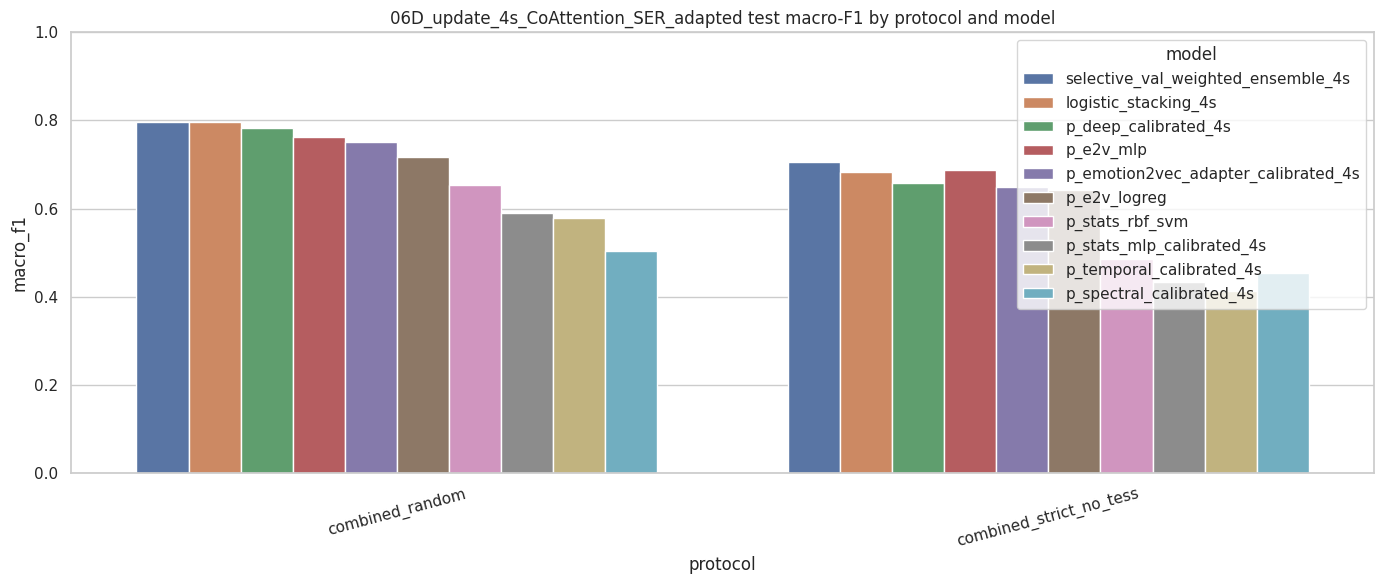

Saved: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs/figures/06D_update_4s_CoAttention_SER_adapted_macro_f1_leaderboard.png


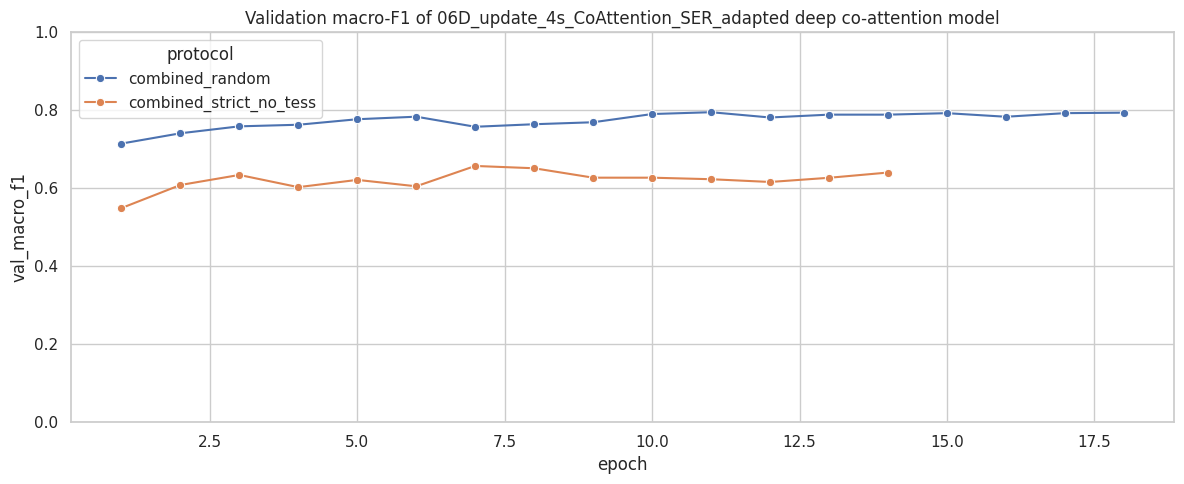

Saved: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs/figures/06D_update_4s_CoAttention_SER_adapted_training_curves.png


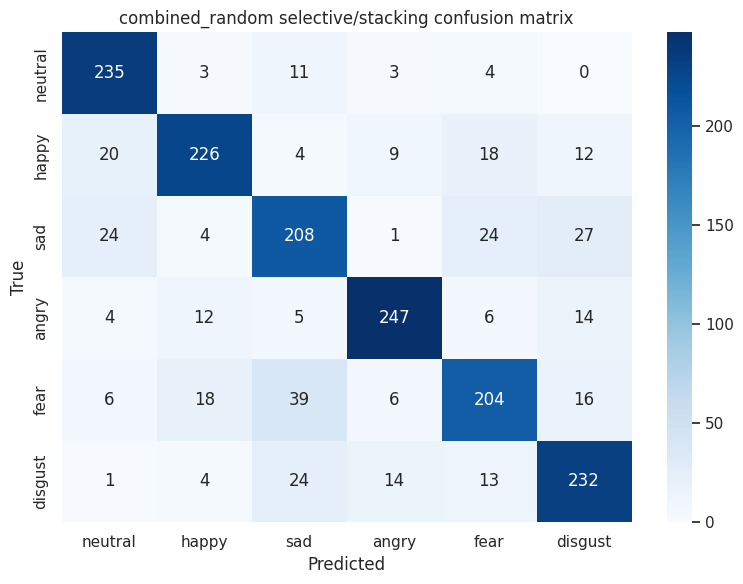

Saved: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs/figures/06D_update_4s_CoAttention_SER_adapted_combined_random_confusion_matrix.png


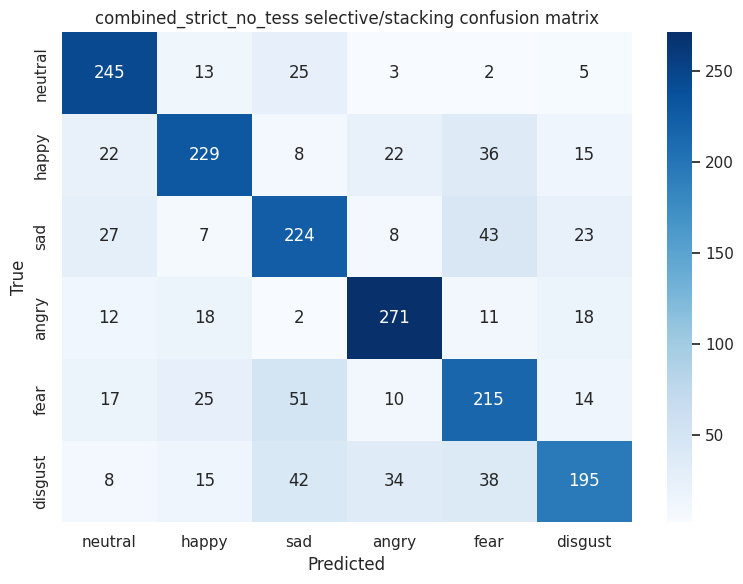

Saved: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs/figures/06D_update_4s_CoAttention_SER_adapted_combined_strict_no_tess_confusion_matrix.png


In [14]:
if len(metrics_df):
    plt.figure(figsize=(14, 6))
    plot_df = metrics_df[metrics_df["split"].eq("test")].copy()
    sns.barplot(data=plot_df, x="protocol", y="macro_f1", hue="model")
    plt.ylim(0, 1)
    plt.title(f"{RUN_ID} test macro-F1 by protocol and model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    fig_path = FIGURE_DIR / f"{RUN_ID}_macro_f1_leaderboard.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

if len(history_df):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="protocol", marker="o")
    plt.ylim(0, 1)
    plt.title(f"Validation macro-F1 of {RUN_ID} deep co-attention model")
    plt.tight_layout()
    fig_path = FIGURE_DIR / f"{RUN_ID}_training_curves.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

for protocol_name, result_pack in protocol_results.items():
    result = result_pack.get("selective", {}).get("test")
    if result is None:
        result = result_pack.get("stacking")
    if result is None:
        continue
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=list(ID_TO_LABEL.keys()))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.title(f"{protocol_name} selective/stacking confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    fig_path = FIGURE_DIR / f"{RUN_ID}_{protocol_name}_confusion_matrix.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)


domain_gate_rows = []
for protocol_name, result_pack in protocol_results.items():
    result = result_pack.get("deep", {}).get("test")
    if result is None or "gate_weights" not in result:
        continue
    idx = result["indices"]
    gate = result["gate_weights"]
    for dataset_name in sorted(metadata.loc[idx, "dataset"].unique()):
        mask = metadata.loc[idx, "dataset"].to_numpy() == dataset_name
        row = {"protocol": protocol_name, "true_dataset": dataset_name, "n_samples": int(mask.sum())}
        for domain_i, domain_name in ID_TO_DOMAIN.items():
            row[f"avg_gate_{domain_name}"] = float(gate[mask, domain_i].mean())
        domain_gate_rows.append(row)

domain_gate_df = pd.DataFrame(domain_gate_rows)
if len(domain_gate_df):
    gate_path = REPORT_DIR / f"{RUN_ID}_domain_gate_summary.csv"
    domain_gate_df.to_csv(gate_path, index=False)
    display(domain_gate_df)
    heat_cols = [c for c in domain_gate_df.columns if c.startswith("avg_gate_")]
    for protocol_name in domain_gate_df["protocol"].unique():
        sub = domain_gate_df[domain_gate_df["protocol"].eq(protocol_name)].set_index("true_dataset")[heat_cols]
        sub.columns = [c.replace("avg_gate_", "") for c in sub.columns]
        plt.figure(figsize=(8, 4))
        sns.heatmap(sub, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
        plt.title(f"Domain gate mixture weights - {protocol_name}")
        plt.ylabel("True dataset")
        plt.xlabel("Adapter/domain weight")
        plt.tight_layout()
        fig_path = FIGURE_DIR / f"{RUN_ID}_{protocol_name}_domain_gate_heatmap.png"
        plt.savefig(fig_path, dpi=180)
        plt.show()
        print("Saved:", fig_path)


In [15]:
reference_rows = [
    {
        "model": "ADDoG / MADDoG domain generalization for cross-corpus SER",
        "protocol": "cross-corpus SER; domain generalization reference",
        "reported_accuracy_text": "Use as domain/corpus generalization reference, not direct 4-corpus benchmark.",
        "main_idea": "Learn representations that reduce unwanted corpus/domain variation for SER.",
        "link": "https://arxiv.org/abs/1903.12094",
    },
    {
        "model": "Cross-corpus SER multi-domain study",
        "protocol": "cross-corpus and multi-domain SER",
        "reported_accuracy_text": "Shows performance degradation and need for adaptation across datasets.",
        "main_idea": "Studies dataset/corpus shift and domain adaptation for emotion recognition.",
        "link": "https://arxiv.org/abs/2207.02104",
    },
    {
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "protocol": "single-dataset, split not clearly strict speaker-aware",
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "main_idea": "Handcrafted features, augmentation, recurrent CNN variants, weighted ensemble.",
        "link": "https://arxiv.org/abs/2112.05666",
    },
    {
        "model": "CA-MSER co-attention multi-level acoustic information",
        "protocol": "IEMOCAP speaker-independent style in paper; not same as our 4-corpus setup",
        "reported_accuracy_text": "Reported on IEMOCAP; use as fusion reference, not direct 6-class benchmark.",
        "main_idea": "MFCC/spectrogram/high-level embedding fusion with co-attention.",
        "link": "https://arxiv.org/abs/2203.15326",
    },
    {
        "model": "emotion2vec frozen/pretrained representation",
        "protocol": "pretrained representation; downstream varies by dataset",
        "reported_accuracy_text": "Use as representation reference; not directly comparable to our split.",
        "main_idea": "Self-supervised speech emotion representation used with lightweight downstream classifier.",
        "link": "https://arxiv.org/abs/2312.15185",
    },
    {
        "model": "Ullah et al. 1D-CNN feature fusion",
        "protocol": "combined 4-dataset, split details not fully reproducible from local materials",
        "reported_accuracy_text": "CREMA-D + RAVDESS + SAVEE + TESS: 92.62%",
        "main_idea": "ZCR + energy + entropy of energy + RMS + MFCC -> 1D-CNN.",
        "link": "https://doi.org/10.1109/ICIT56493.2022.9989197",
    },
]
ref_df = pd.DataFrame(reference_rows)
ref_df.to_csv(REPORT_DIR / f"{RUN_ID}_reference_model_comparison.csv", index=False)
display(ref_df)


,model,protocol,reported_accuracy_text,main_idea,link
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, split not clearly strict speak...",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Handcrafted features, augmentation, recurrent ...",https://arxiv.org/abs/2112.05666
1,CA-MSER co-attention multi-level acoustic info...,IEMOCAP speaker-independent style in paper; no...,"Reported on IEMOCAP; use as fusion reference, ...",MFCC/spectrogram/high-level embedding fusion w...,https://arxiv.org/abs/2203.15326
2,emotion2vec frozen/pretrained representation,pretrained representation; downstream varies b...,Use as representation reference; not directly ...,Self-supervised speech emotion representation ...,https://arxiv.org/abs/2312.15185
3,Ullah et al. 1D-CNN feature fusion,"combined 4-dataset, split details not fully re...",CREMA-D + RAVDESS + SAVEE + TESS: 92.62%,ZCR + energy + entropy of energy + RMS + MFCC ...,https://doi.org/10.1109/ICIT56493.2022.9989197


## Save Output Package

Cell cuối đóng gói output nhẹ để tải về từ Kaggle:

- `reports/`: metrics, history, per-dataset, batch log, ensemble weights, domain gate summary, summary JSON;
- `figures/`: leaderboard, training curve, confusion matrix, domain gate heatmap;
- `models/`: checkpoint best model;
- `predictions/`: prediction CSV kèm confidence và domain mixture weights.

Cache feature thường rất lớn nên không zip mặc định. Nếu cần giữ cache, tải riêng file `.npz` trong `cache/`.

In [16]:
summary = {
    "notebook": RUN_ID,
    "objective": "06F Domain-Aware Mixture Adapter SER: frozen emotion2vec, temporal/spectral/stat branches, co-attention, soft domain gate, dataset adapters, domain auxiliary loss, selective ensemble.",
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(metrics_path),
    "history_csv": str(history_path),
    "per_dataset_csv": str(per_dataset_path),
    "ensemble_weights_csv": str(ensemble_weights_path),
    "batch_log_csv": str(batch_log_path),
    "domain_gate_summary_csv": str(REPORT_DIR / f"{RUN_ID}_domain_gate_summary.csv"),
    "protocols": [name for name, _ in protocols],
    "labels": COMMON_EMOTIONS,
    "domain_names": DOMAIN_NAMES,
    "target_duration": TARGET_DURATION,
    "ablation_durations": ABLATION_DURATIONS,
    "preprocess": {
        "target_sr": TARGET_SR,
        "trim_silence": TRIM_SILENCE,
        "trim_top_db": TRIM_TOP_DB,
        "loudness_normalize": LOUDNESS_NORMALIZE,
        "target_rms_dbfs": TARGET_RMS_DBFS,
        "audio_crop_mode": AUDIO_CROP_MODE,
    },
    "loss_weights": {
        "aux_loss_weight": AUX_LOSS_WEIGHT,
        "domain_loss_weight": DOMAIN_LOSS_WEIGHT,
        "gate_entropy_weight": GATE_ENTROPY_WEIGHT,
    },
    "calibration": {
        "temperature_scaling": USE_TEMPERATURE_SCALING,
    },
    "ensemble": {
        "selective_min_val_macro_f1": SELECTIVE_MIN_VAL_MACRO_F1,
        "selective_relative_f1": SELECTIVE_RELATIVE_F1,
        "selective_weight_power": SELECTIVE_WEIGHT_POWER,
        "logistic_stacking": RUN_LOGISTIC_STACKING,
    },
    "emotion2vec_model": EMOTION2VEC_MODEL,
    "notes": "Validation split is used for calibration, selective weighting and logistic stacking. Test split is only used for final reporting. Cache is excluded from the light zip.",
}
with open(REPORT_DIR / f"{RUN_ID}_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

light_zip_path = PROJECT_ROOT / f"{RUN_ID}_outputs_light_no_cache.zip"
include_dirs = {
    "reports": REPORT_DIR,
    "figures": FIGURE_DIR,
    "models": MODEL_DIR,
    "predictions": PRED_DIR,
}

with zipfile.ZipFile(light_zip_path, "w", compression=zipfile.ZIP_DEFLATED, allowZip64=True) as zf:
    for folder_name, folder in include_dirs.items():
        folder = Path(folder)
        if not folder.exists():
            print(f"Skip missing folder: {folder_name} -> {folder}")
            continue
        file_count = 0
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                zf.write(file_path, file_path.relative_to(OUTPUT_DIR))
                file_count += 1
        print(f"Added {folder_name}: {file_count} files")

with zipfile.ZipFile(light_zip_path, "r") as zf:
    bad_file = zf.testzip()
    zip_files = zf.namelist()

print("LIGHT ZIP:", light_zip_path)
print("ZIP size MB:", round(light_zip_path.stat().st_size / (1024 * 1024), 2))
print("ZIP integrity:", "OK" if bad_file is None else f"BAD FILE: {bad_file}")
print("Total files in zip:", len(zip_files))
print("First files:", zip_files[:20])
print("Download this zip from Kaggle Output panel.")
light_zip_path

Added reports: 8 files
Added figures: 4 files
Added models: 2 files
Added predictions: 20 files
LIGHT ZIP: /kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs_light_no_cache.zip
ZIP size MB: 20.96
ZIP integrity: OK
Total files in zip: 34
First files: ['reports/06D_update_4s_CoAttention_SER_adapted_history.csv', 'reports/06D_project_strict_split_by_dataset.csv', 'reports/06D_update_4s_CoAttention_SER_adapted_summary.json', 'reports/06D_update_4s_CoAttention_SER_adapted_batch_log.csv', 'reports/06D_update_4s_CoAttention_SER_adapted_metrics.csv', 'reports/06D_update_4s_CoAttention_SER_adapted_per_dataset.csv', 'reports/06D_update_reference_model_comparison.csv', 'reports/06D_update_4s_CoAttention_SER_adapted_selective_ensemble_weights.csv', 'figures/06D_update_4s_CoAttention_SER_adapted_macro_f1_leaderboard.png', 'figures/06D_update_4s_CoAttention_SER_adapted_training_curves.png', 'figures/06D_update_4s_CoAttention_SER_adapted_combined_strict_no_tess_confusion_matrix.png', 'figu

PosixPath('/kaggle/working/06D_update_4s_CoAttention_SER_adapted_outputs_light_no_cache.zip')